#  **🧠 Decode the Brain: Tumor Detection with AI Magic 🔮**

# <div class="header1"> Introduction 👋</div>
<center>

 # What is Brain Tumor?

<img src="https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExMWk5b3d5d2poeW8wODA0cXR5NjB2aWt5a205YXR4cndvMXZqdmFycSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/xT0BKr4MvHdohFTe6s/giphy.gif">                   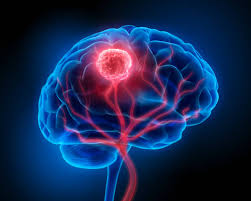


A brain tumor is a collection, or mass, of abnormal cells in your brain. Your skull, which encloses your brain, is very rigid. Any growth inside such a restricted space can cause problems. Brain tumors can be cancerous (malignant) or noncancerous (benign). When benign or malignant tumors grow, they can cause the pressure inside your skull to increase. This can cause brain damage, and it can be life-threatening. Brain tumors are categorized as primary or secondary:


*   A primary brain tumor originates in your brain. Many primary brain tumors are benign.
*   A secondary brain tumor, also known as a metastatic brain tumor, occurs when cancer cells spread to your brain from another organ, such as lung or breast.



# How is Brain Tumor diagnosed?
**Magnetic Resonance Imaging (MRI)**


*   An MRI uses magnetic fields to produce detailed images of the body.
MRI can be used to measure the tumor’s size. A special dye called a contrast medium is given before the scan to create a clearer picture.
*   This dye can be injected into a patient’s vein or given as a pill or liquid to swallow.
MRIs create more detailed pictures than CT scans and are the preferred way to diagnose a brain tumor.

*   The MRI may be of the brain, spinal cord, or both, depending on the type of tumor suspected and the likelihood that it will spread in the CNS.
*   There are different types of MRI. The results of a neuro-examination, done by the internist or neurologist, helps determine which type of MRI to use.





#The Importance of Brain Tumor Classification

The early detection and classification of brain tumors are crucial areas of research in medical imaging. Accurate classification aids in selecting the most suitable treatment method, potentially saving patients' lives.

# What do the Numbers Say?
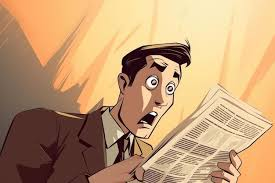

*   In Pakistan, it is estimated that 15,000–20,000 people are diagnosed with a brain tumor every year. Alarmingly, a significant percentage of these cases involve children, particularly those affected by aggressive tumor types like  glioma etc.
*   With a national population of approximately **241 million**, this means that only about **0.006%** of the population is diagnosed with a brain tumor annually.





#Application of Deep Learning
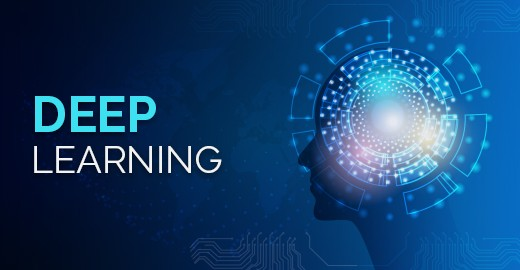

The application of deep learning approaches in healthcare has yielded significant advancements in health diagnosis. According to the World Health Organization (WHO), effective brain tumor diagnosis involves detecting the tumor, identifying its location within the brain, and classifying it based on malignancy, grade, and type. This experimental work focuses on diagnosing brain tumors using Magnetic Resonance Imaging (MRI). The process entails tumor detection, classification by grade and type, and identification of the tumor's location. Instead of employing individual models for each classification task, this method utilizes a single model for classifying brain MRI images across different classification tasks. The classification and detection of tumors employ a Convolutional Neural Network (CNN)-based multi-task approach. Additionally, a CNN-based model is employed to segment the brain and identify the location of the tumor.



# 📌 Notebook Objectives
<img src="https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExd2pqdzNpeXR6Z3RxeGJ2MWh0YWRuZjJ1czlqanExdXJlaHFxbGVmbyZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/Uu5MHCPoCabaLUYUgE/giphy.gif">

This notebook aims to:
*   Perform dataset exploration using various types of data visualization.
*   Perform Image Preprocessing, Image Analysis, Label Encoding, etc..





*   Build a deep learning model that can predict Brain Tumor.
*   Save the model.

*   Test the model on Test Data








# Importing Libraries 📚

In [ ]:
import os # For directory and file operations
import numpy as np # For numerical operations and handling image arrays
import random # For generating random values for augmentation
from PIL import Image, ImageEnhance # For image processing and enhancement
from matplotlib import pyplot as plt # For plotting information

#keras
from tensorflow.keras.models import Sequential # For building the model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout # For model layers
from tensorflow.keras.preprocessing.image import load_img # For loading images
from tensorflow.keras.optimizers import Adam # For optimizer
from tensorflow.keras.applications import VGG16 # For using VGG16 model
from sklearn.utils import shuffle # For shuffling the data

# 🧾 DataSet Handeling

Dataset Description

The dataset comprises a total of 7023 human brain MRI images, categorized into four distinct classes. The dataset focuses on brain tumors and their classification. The four classes are as follows:


*   **Glioma:** Cancerous brain tumors in glial cells.
*   **Meningioma:** Non-cancerous tumors originating from the meninges.

*   **Pituitary:** Tumors affecting the pituitary gland, which can be cancerous or non-cancerous.
*   **No Tumor:** Normal brain scans without detectable tumors.








**Load Directories for training and testiing data**

In [ ]:
train_dir = '/content/drive/MyDrive/MRI Images/Training/'
test_dir = '/content/drive/MyDrive/MRI Images/Testing/'

**Load and shuffle the train data**

In [ ]:
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
  #print(label)
  for image in os.listdir(os.path.join(train_dir, label)):
    #print(image)
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

#train_paths

**Load and shuffle the test data**

In [ ]:
#Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
  #print(label)
  for image in os.listdir(os.path.join(test_dir, label)):
    #print(image)
    test_paths.append(os.path.join(test_dir, label, image))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

#test_paths

# Data Visualization

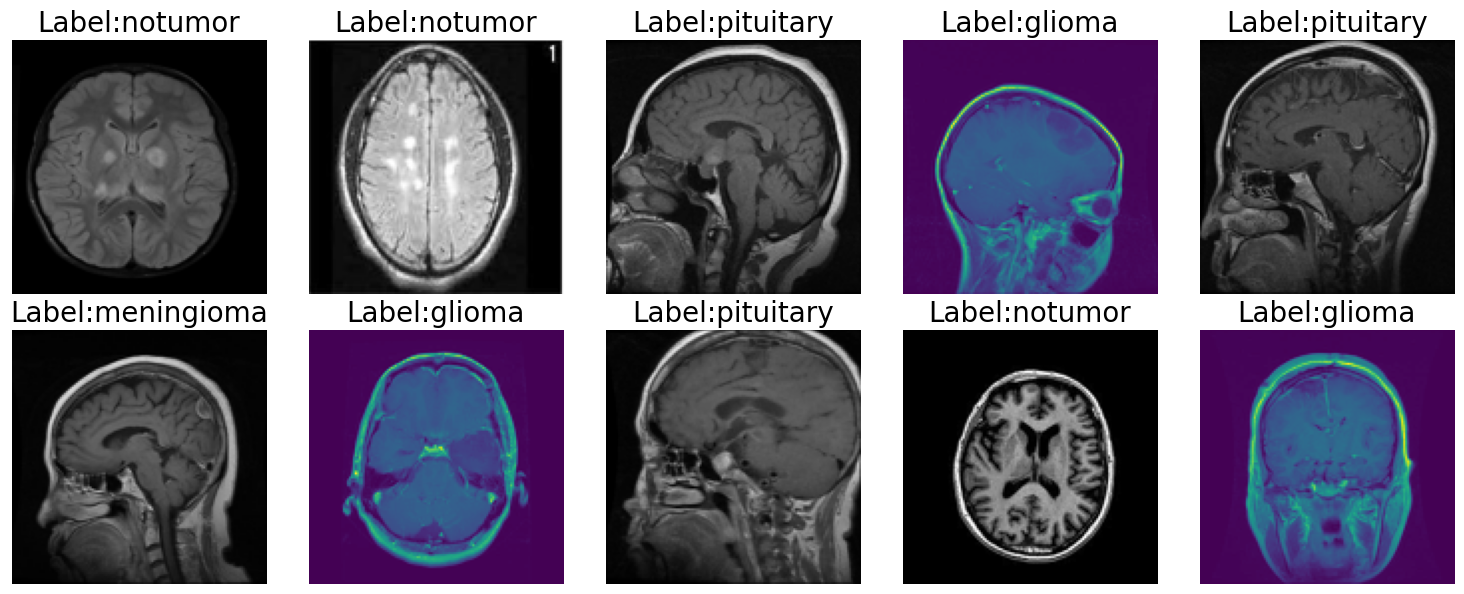

In [ ]:
import random
import matplotlib.pyplot as plt

#select random indices for 10 images
random_indices = random.sample(range(len(train_paths)),10)

#create a figure to display images in two rows
fig, axes = plt.subplots(2, 5, figsize=(15,6))
axes = axes.ravel()
#loop through the random indices and display images
for i,idx in enumerate(random_indices):
  #print(i,idx)
  img_path = train_paths[idx]
  img=Image.open(img_path)
  img=img.resize((128,128))
  #display images
  axes[i].imshow(img)
  axes[i].axis('off')
  axes[i].set_title(f"Label:{train_labels[idx]}",fontsize=20)

plt.tight_layout()
plt.show()



## Image Preprocessing

**Image Augmentation function**

In [ ]:
#the data augmentation is taking a image and our objective is to preprocess the image, scaling of image,enhancement of image
#it should return a preprocessesd image with augmentation
#so first of all our image with the help of pillow library class .fromarray which is numpy array and i will take it in a pillow library format
#for that inside numpy ,datatype of image which in unsigned integer8 and then pass it a image
def augment_image(image): #augment image function which will take an image and then will a augmented image.
  image = Image.fromarray(np.uint8(image))
  # convert image to unsigned integer(uint8) using numpy functin np.unit8(image)
  # after that using numpy array .fromarray and this Image class i take it into
  # pillow image "image=" because the enhancement which i am going to perform
  # and its class provided me by pillow library and it have to take image in
  # pillow format so i will call brightness from the image enhancement class
  # which i have already imported and pass it my image and enhance it in the
  # sense that image is not already bright so increase its brightness so that
  # augmentation wil come in my data, but we have to tell the ratio of that
  # enhancement and for that from random inside uniform i will give ratio b/w
  # 0.8 and 1.2 by .enhance(random.uniform(0.8,1.2)) so the image that is coming
  # from the dataset and is greater than 1.0 then make it dark(low the
  # brightness) and if image is less than 1.0 than increase the brightness

  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8,1.2))
  #now also do contrast along brightness
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))
  #this function will return the augmented image of pillow version so we have to re convert it into numpy array
  #but before converting we also need to scale the image
  #as we know the image is 2d for example if i show the values behind the image
  """
  [
      [20,30,50,150,30.0,0],
      [30,40,50]
  ]
  """
  #etc.....which represents the pixels
  # value of ever image will be b/w 0-255, lower the value repreesents darkness,
  # higher the value represents brightness
  #we have to bring like all these values[20,30,40,50] = [0,1,,1] so that model will give each value equal importance
  #it is normalization in image preprocessing
  image = np.array(image) / 255.0
  return image # now we are returning the preprocessed image

**Load images and apply augmentation**

In [ ]:
#as we have to read the image in this form[10,20,30,40] i.e pixel values
def open_images(paths):
  #so i make a list ,path contains images and then i implement the loop and loop will continues ,no of images
  images = []
  for path in paths:
    #will read image everytime using load function of keras library
    img = load_img(path, target_size=(IMAGE_SIZE,IMAGE_SIZE)) # path and size of image , in my case 128 x 128
    #now the image we have read we have to preprocess that image for which we already have our'augment function',so simply we call that
    img = augment_image(img) #this will give a prepocessed img
    #now we have the img and we have to append that img in the list images[]
    images.append(img)
  return np.array(images) #return the images in nparray
  #now (images) array contains pixel value of every image

**Encoding labels (convert label names to integers)**

In [ ]:
#notumor = 0
#glioma = 1
#meningioma = 2
#pituitary = 3

# so total we have 4 classes ,encoder function is used to convert string into integer values.

#encoder labels(convert label names to integers
def encode_label(labels):  # will take labels and convert into integers
  #to convert first we have to get the unique label
  unique_labels = os.listdir(train_dir)
  #so in list i will run a loop which will run 4 times and will take the name of 4 labels  [for label in unique_labels]
  #to convert i will call unique_labels and then its index and pass the label of loop
  encoded = [unique_labels.index(label) for label in labels]
  #now this will contain [0,1,2,3]
  return np.array(encoded)


**Data generator for batching**

In [ ]:
#as in deep learning when we train the model it takes time in training,so we read data in batches
# we give data to model in batches whhich saves time and memory as well and speed of model and proformance increases.
#now this last function is important as all other functions are dependent on it
"""
def datagen(paths,labels,batch_size=12, epochs=1):#for default once i take batch_size=12, epochs=1
  #now we have to run a loop with convention in range of epochs,
  #so this loop will run 5 times because epochs are 5
  #first time it will read the data in 12 batches
  for _ in range(epochs):
    #within this  will run another loop which will run the number of times the images are from 0... with batch size
    for i in range(0, len(paths),batch_size):
      #do indexing in paths for batch
      batch_paths = paths[i:i+batch_size] # take the image of inner loop and join it with batch size, so 12 images will come in first batch
      batch_images = open_images(batch_paths) #will open the image using open images function
      #now for labels
      batch_labels = labels[i:i+batch_size]
      batch_labels = encode_label(batch_labels)
      yield batch_images, batch_labels
"""
# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch

**Print unique labels**

In [ ]:
unique_labels = (os.listdir(train_dir))
print("Class to Integer Mapping:")
for idx, label in enumerate(unique_labels):
    print(f"{label} = {idx}")

Class to Integer Mapping:
notumor = 0
glioma = 1
meningioma = 2
pituitary = 3


#  Model Training & Implementation 🛠️
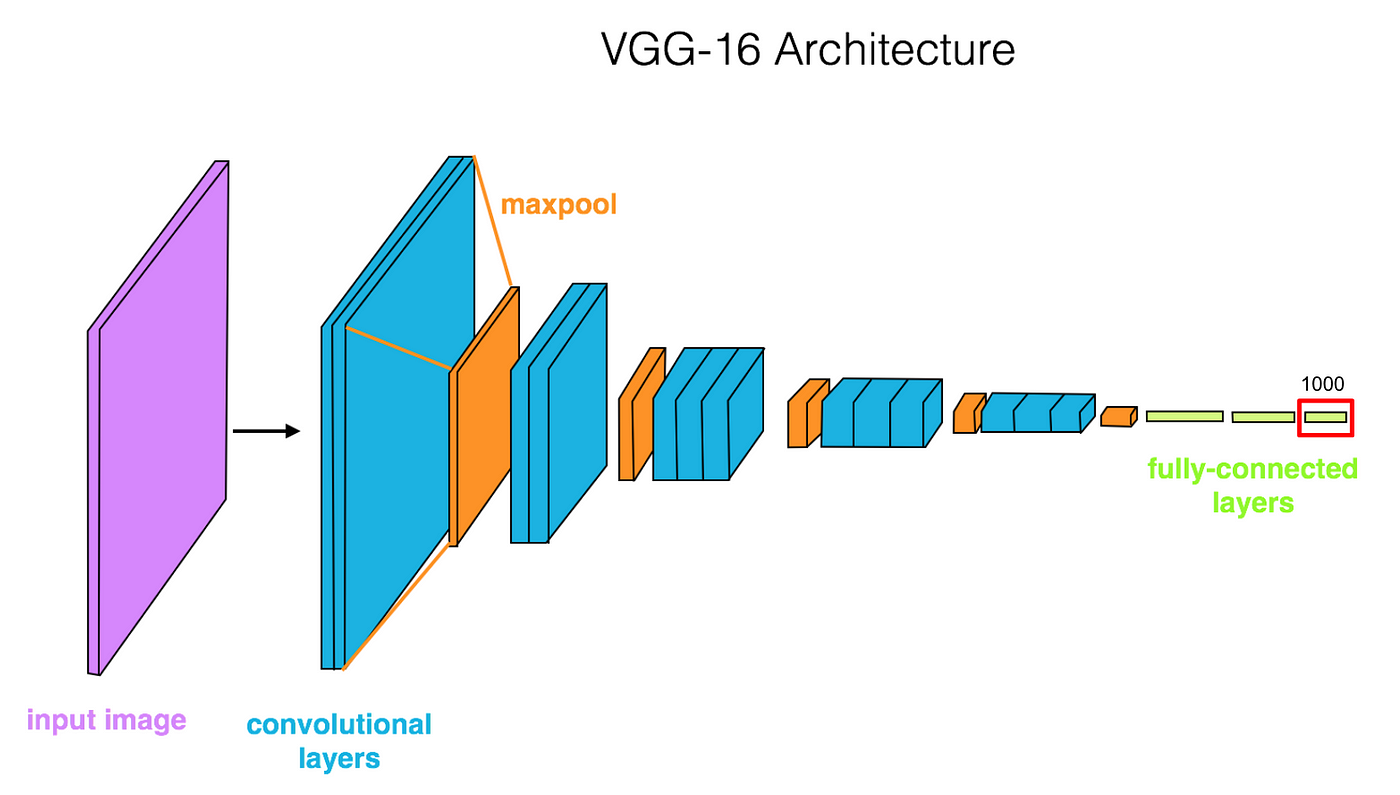

VGG16 is a popular Convolutional Neural Network (CNN) architecture developed by the Visual Geometry Group (VGG) at the University of Oxford. It was introduced by Simonyan and Zisserman in their 2014 paper:

“Very Deep Convolutional Networks for Large-Scale Image Recognition”

It became widely known for its performance in the ImageNet Large Scale Visual Recognition Challenge (ILSVRC 2014).

**🔧 Architecture Highlights**



*   16 layers with learnable weights (13 convolutional + 3 fully connected)
*   Uses only 3×3 convolution filters with stride 1 and same padding


*   Max pooling with 2×2 filters and stride 2
*   Ends with 3 Fully Connected (Dense) layers

*   Total parameters: ~138 million








**✅ Key Features**



*   Simple and uniform architecture
*   Easy to implement and modify

*   Performs well on image classification tasks
*   Often used as a feature extractor in transfer learning





**📦 Applications**


*   Image classification
*   Feature extraction

*   Medical imaging (e.g., brain tumor detection)
*   Transfer learning in CNN pipelines





**Build and Train Model**

In [ ]:
#Model Architecture RGB(128,128,3)
# every image width=128,height=128 with 3 colour channels
IMAGE_SIZE = 128
#since the model is pretrained which is trained on a very large data and have soo many layers but i want to train it on my data so that i dont want to include its top layers
base_model = VGG16(input_shape=(IMAGE_SIZE,IMAGE_SIZE,3),include_top=False, weights='imagenet') #width ,height , channel-----,parameter =include_top=False,pretrained weights=data imagenet is used because its reults are very good.
# VGG16 this model have soo many layers such as i dont need top classification layers so it put it on false, that i will build for my coustom data.
#i only need the model VGG16 knowledge and knowledge is provided by these weights 'imagenet'.
# imagenet is that data which was used when the model was trained and that had given very good results.

#freeze all layers of the VGG16 model and for this i will use a loop and take layer one by one,but i need second last ,third last and fourth last layers, so i have to un freeze that layers

for layer in base_model.layers:
  layer.trainable = False

#set only the last few layers
base_model.layers[-2].trainable = True #second last
base_model.layers[-3].trainable = True #third last
base_model.layers[-4].trainable = True #fourth last

#now build model
model = Sequential() #help to build layers in neural network
#now i add layers in my model
#first layer will be the input lapyer of my model
model.add(Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3))) #input layer =width,height and three colour channel
#now to add transfer learning knowledge of model in layer
model.add(base_model) #VGG16 model
# the output of this model for image will be multidimensional but i only need 1d, so i will flatten it
model.add(Flatten()) #Flatten layer
# as this is input layer and the model can become overfit ,try to train extreemly high on data.
#so we have to add dropout layer which is used to drop randomly 30% neurons from model to make less chances of overfiting
model.add(Dropout(0.3))
#now for the fully connected layer
model.add(Dense(128, activation='relu')) #dense layer    neurons=128, activation function=relu
model.add(Dropout(0.2)) #dropout layer----will drop 20% data

#now the last thing to do is to ad output layer in which we tell weather it is binary classification, multiclass classification
#add classes in dense layer.
# we know that how many classes we have but our model dont know, "os.listdir(train_dir)# to get classes"

model.add(Dense(len(os.listdir(train_dir)), activation='softmax')) #output layer-------we will use activation function in output layer depending upon the problem and for this case (multi-class we will use 'softmax')
# in this model.add(Dense(len(os.listdir(train_dir)))), i have told my model to work on 4 classes ,means--MULTICLASS CLASSIFICATION--


#now we have to compile the model, and call compile method inside model and give it a optimizer which will be ADAM which i have already import ,learning rate =initially my learning rate will be 0.0001
#as deep learning neural network there is back propagation in which the weights are updated on the basis of learning rate. and my loss calculation function in case of multi class classification will be 'sparse_catagorical_crossentropy'
#if the case is binary classification then we use loss= categorical_crossentropy
#the last thing we will add is metrices
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])


# to train the model we have to set couple of parameters

#parameters
batch_size = 20 # if want the data to be read in 20 batch size
#now to calculate step of each batch= first i will take len of images in my data and then i will divide it by the batch size
steps = int(len(train_paths) / batch_size)
# now i have to train my model five time i.e epochs
epochs = 50

# train model
# i also want to store it in history while training, and pss some things in mode.fit like a function which i have made before "datagen" and will give it train dataset and the train labels , batch size which is a parameter and i will pass it my batch size and epochs
 #as defined already steps = int(len(train_paths) / batch_size)
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)
# the model is getting training data , its labels , batch size, steps which it will take after each epoch to give me results

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 3316s 12s/step - loss: 0.6257 - sparse_categorical_accuracy: 0.7502
Epoch 2/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - loss: 0.2641 - sparse_categorical_accuracy: 0.9008
Epoch 3/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 29s 102ms/step - loss: 0.1675 - sparse_categorical_accuracy: 0.9393
Epoch 4/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 29s 101ms/step - loss: 0.1125 - sparse_categorical_accuracy: 0.9615
Epoch 5/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 28s 99ms/step - loss: 0.0831 - sparse_categorical_accuracy: 0.9696
Epoch 6/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 28s 99ms/step - loss: 0.0521 - sparse_categorical_accuracy: 0.9808
Epoch 7/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 28s 99ms/step - loss: 0.0541 - sparse_categorical_accuracy: 0.9806
Epoch 8/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 28s 99ms/step - loss: 0.0375 - sparse_categorical_accuracy: 0.9856
Epoch 9/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 28s 99ms/step - loss: 0.0395 - sparse_categorical

# Train and Val Plots

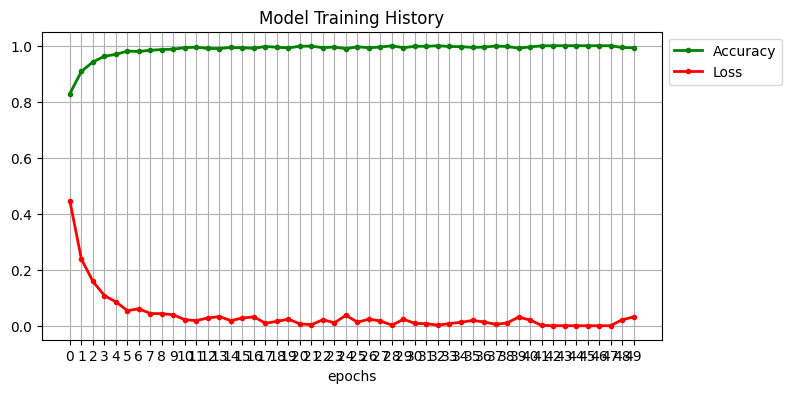

In [ ]:
#as we have saved the results of model in history
plt.figure(figsize=(8,4)) #width=8, height=4
#as i need fig in grid
plt.grid(True)
#now i will call the plot in plt and history in which the results are stored, access "sparse_categorical_accuracy"
plt.plot(history.history['sparse_categorical_accuracy'],'.g-',linewidth=2)#acc with green colour('.g-')
#now for loss
plt.plot(history.history['loss'],'.r-', linewidth=2) # with red colour
plt.title('Model Training History') #title
plt.xlabel('epochs') # title of x-axis
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

# Model Classification Report

In [ ]:
#here we can check the model performance for each class
#average acc of model on test data

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np

#now i will take my complete test data
test_images = open_images(test_paths)# open images function and pass test paths
#so that i have read all the test images

#now encode the test labels using encode function
test_labels_encoded = encode_label(test_labels)

#now i can demand prediction from the model
test_predictions = model.predict(test_images) #store it in test predictions , now each class have a probability

print("Classification Report: ")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1))) # axis 1 coloumn wisw comparison b/w test labels and model predictions


41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 178ms/step
Classification Report: 
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       405
           1       0.97      0.95      0.96       300
           2       0.95      0.94      0.95       306
           3       0.99      0.99      0.99       300

    accuracy                           0.97      1311
   macro avg       0.97      0.97      0.97      1311
weighted avg       0.97      0.97      0.97      1311



# Confusion Matrix

Confusion Matrix: 
[[404   1   0   0]
 [  2 284  14   0]
 [  7   6 289   4]
 [  1   1   2 296]]


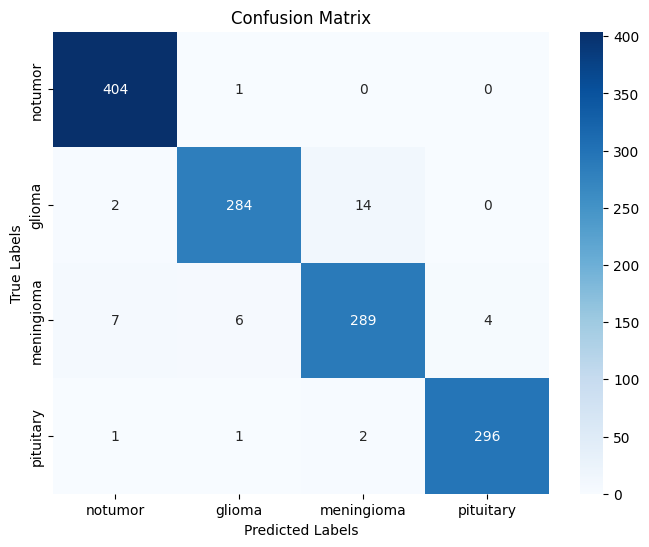

In [ ]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1)) #and call confusion matrix
print("Confusion Matrix: ")
print(conf_matrix)

#plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))# annotation will be ture(values in cells)
#cmap (colour will be blue)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Roc Curve Plot

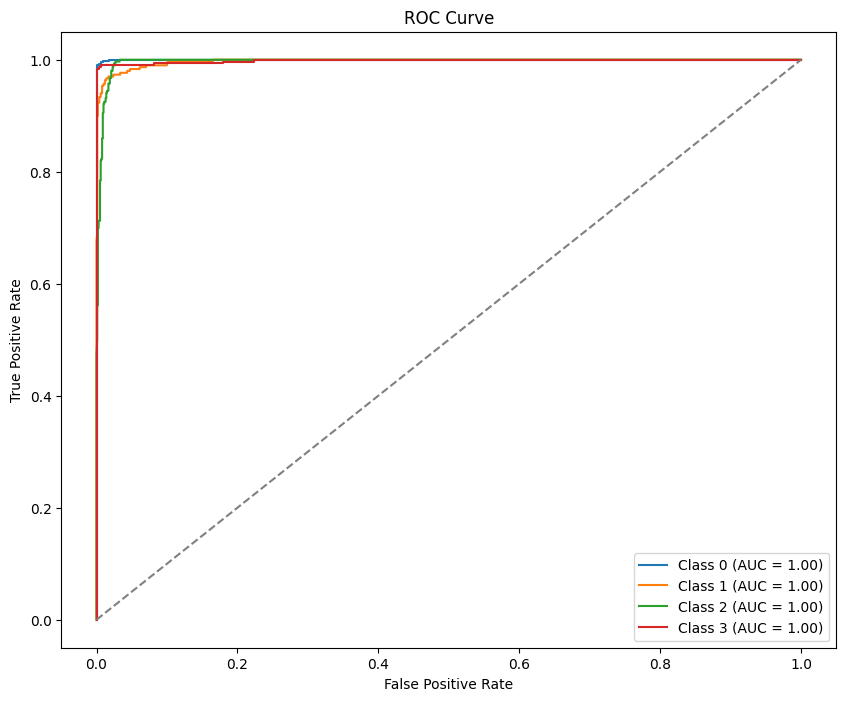

In [ ]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# Save the Model

In [ ]:
#save the entire model
model.save('model.h5')

# Load the Model

In [ ]:
#now i have to test the model on new images
from tensorflow.keras.models import load_model #from this class load_model we can load the saved model
model = load_model('model.h5')

# Check the Model is overfit or not

65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.1420 - sparse_categorical_accuracy: 0.9705
Test Loss: 0.1307651698589325
Test Accuracy: 0.9707692265510559


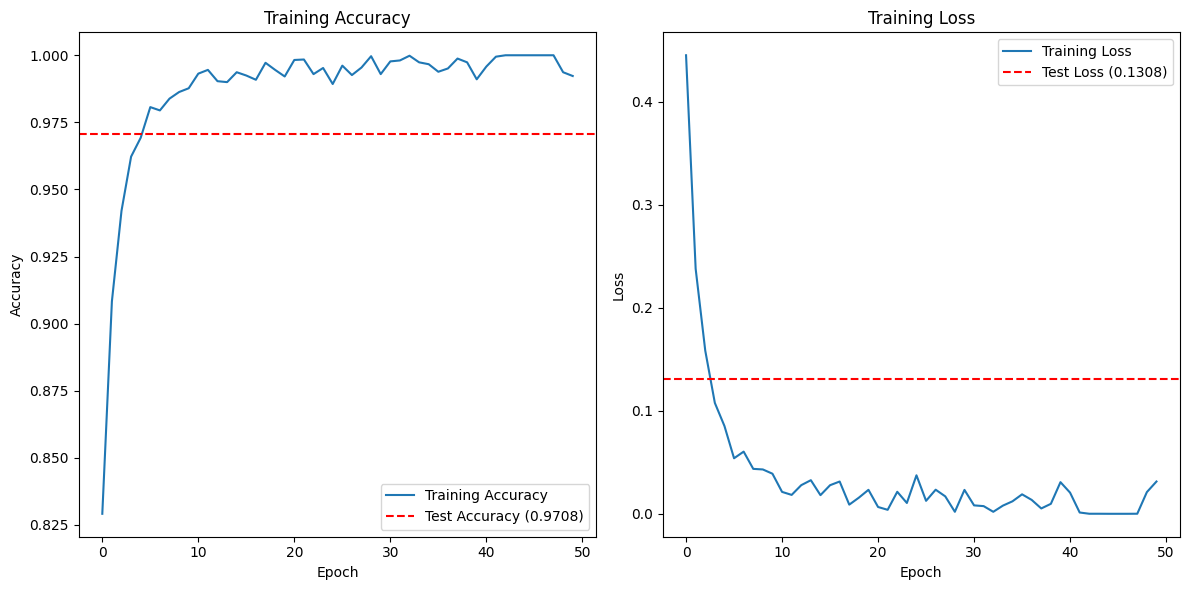

In [ ]:
# To check for overfitting, we need to evaluate the model on the test dataset
# and compare the performance (loss and accuracy) on the training data and the test data.
# We can access the training history (loss and accuracy) from the 'history' object returned by model.fit.

# First, evaluate the model on the test data
test_steps = int(len(test_paths) / batch_size)
# Use the datagen for the test data, but with epochs=1 since we only need to evaluate once
test_generator = datagen(test_paths, test_labels, batch_size=batch_size, epochs=1)

# Evaluate the model on the test set
# The evaluate method returns the loss and metrics for the model in test mode.
loss, accuracy = model.evaluate(test_generator, steps=test_steps)

print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

# Now, plot the training history to visually inspect for overfitting
# Overfitting is typically indicated by a large gap between training accuracy and test accuracy,
# or when training loss continues to decrease while test loss starts to increase.

plt.figure(figsize=(12, 6))

# Plot training accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['sparse_categorical_accuracy'], label='Training Accuracy')
# Note: If you had validation data, you would plot validation accuracy here as well.
# Since we only have training and testing in this setup, we compare training accuracy to the final test accuracy.
plt.axhline(y=accuracy, color='r', linestyle='--', label=f'Test Accuracy ({accuracy:.4f})')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
# Similar to accuracy, compare training loss to the final test loss.
plt.axhline(y=loss, color='r', linestyle='--', label=f'Test Loss ({loss:.4f})')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# **MRI Tumor Detection System**

In [ ]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

class_labels = ['notumor','glioma', 'meningioma','pituitary']

#convert image to array first

#now i will make a function detect and display
def detect_and_display(img_path, model, image_size=128): # it will take tha path of image and my model
  #i will do exceptional handeling and read the image
  try:  # i will do every thing  in try
    #load image
    img = load_img(img_path, target_size=(image_size, image_size))# to load the img i will use the load_img function and give it image path and target size 128x128
    #now we have to convert image into array
    img_array = img_to_array(img) / 255.0  # Normalize pixel values #convert image into array by using this function
    #as the data given to model was in batches
    #so, every img array will have some extra dimension
    #since this is a production system for user
    #a new image is coming from user , so its dimensions can be less
    # so optionally i am expanding the dimensions
    img_array = np.expand_dims(img_array, axis=0)  #expand dimensions row wise
    # did these things so that my model will not confuse as it was trained on batch size

    #will do prediction now
    predictions = model.predict(img_array)
    #now this model will give 4 probabilities for this image as there are 4 classes
    #such as (0=0.90, 1=0.60, 2=0.99, 3=0.40)
    #we will have to get the heighest probability of the class

    #now will pick the heighest predicted class
    predicted_class_index = np.argmax(predictions, axis=1)[0] #using the np argument max function we can do it easily
    #arg max will pick the index of the highest preddicted class and give it to predicted_class

    #here i will find the confidence score(highest probability)
    confidence_score = np.max(predictions, axis=1)[0]#coloum wise from the list


    #here we have to give the complete name of thr predicted class such as notumor so the user can understand
    #for this i am def class labels on top

    #determine the class
    #as we have to give the message of tumour with stage(name of tumor) as well
    if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
    else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

    #now we have to display the image
    #usimg matplot lib
    # Display the image with the prediction
    plt.imshow(load_img(img_path))
    plt.axis('off')
    plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
    plt.show()

  except Exception as e:
        print("Error processing the image:", str(e))


**Predictions on Test Images**

Prediction on Image 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


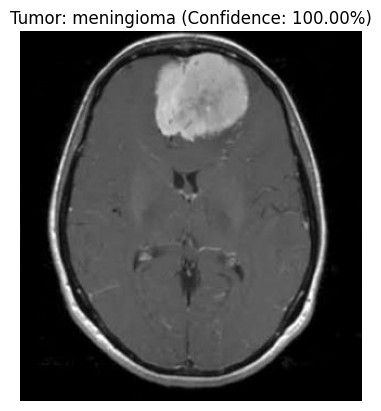

In [ ]:
image_path = '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-me_0027.jpg'
detect_and_display(image_path, model)

Prediction on Image 2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


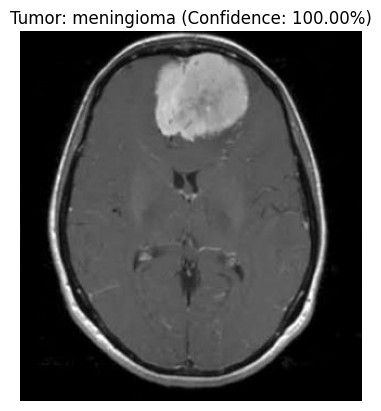

In [ ]:
image_path = '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-me_0027.jpg'
detect_and_display(image_path, model)

Prediction on Image 3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


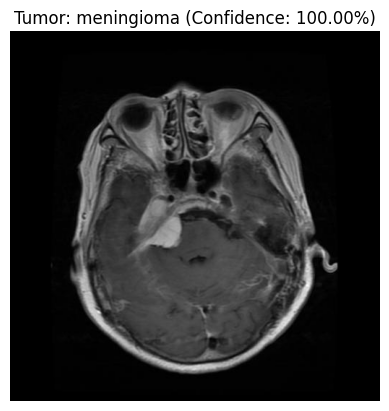

In [ ]:
image_path = '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-me_0159.jpg'
detect_and_display(image_path, model)

Prediction on Image 4

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


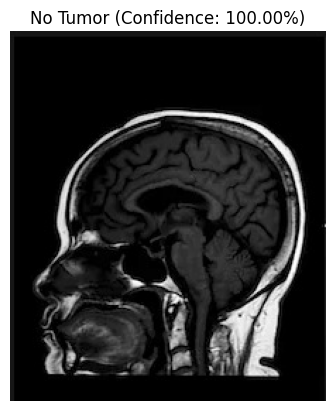

In [ ]:
image_path = '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-noTr_0004.jpg'
detect_and_display(image_path, model)

Prediction on Image 5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step


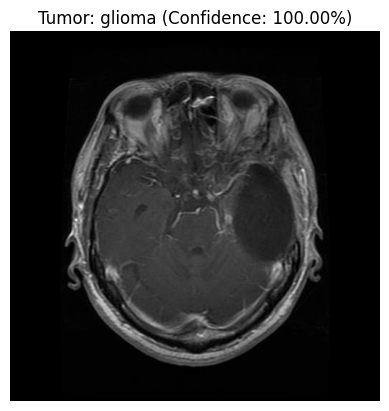

In [ ]:
image_path = '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0015.jpg'
detect_and_display(image_path, model)

Prediction on Image 6

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step


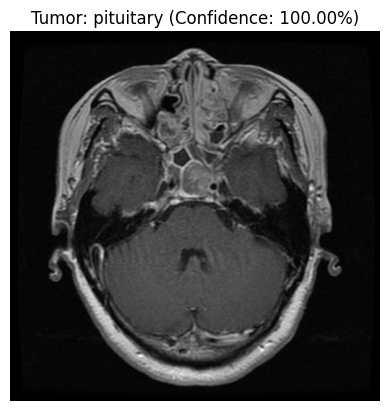

In [ ]:
image_path = '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_0059.jpg'
detect_and_display(image_path, model)